<a href="https://colab.research.google.com/github/anastasiam1165-beep/Job-Market-Insight-Project/blob/main/Project_Job_Market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
data_path = '/content/drive/MyDrive/Personal Projects/job_market.csv'
df = pd.read_csv(data_path)

# preview data
df.info()    #displays information about each column including its data type
df.head()    #prints the first five rows of the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            250 non-null    object 
 1   company              250 non-null    object 
 2   location             250 non-null    object 
 3   job_type             221 non-null    object 
 4   category             230 non-null    object 
 5   salary_min           250 non-null    int64  
 6   salary_max           250 non-null    int64  
 7   experience_required  207 non-null    float64
 8   publication_date     250 non-null    object 
 9   skills               200 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 19.7+ KB


,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills
0,Engineering Manager,DataInc,"San Francisco, CA",Remote,Technology,151082,291345,4.0,2025-11-27,"AWS, Agile, Machine Learning, Kubernetes, Mong..."
1,Engineering Manager,EnterpriseHub,"New York, NY",Remote,Technology,156891,280075,3.0,2025-11-27,"Java, Agile, Git, SQL, Ruby, Go"
2,Engineering Manager,StartupXYZ,"Seattle, WA",Part-time,Technology,152134,280310,4.0,2025-11-27,"AWS, Python, Kubernetes, Git"
3,Lead Engineer,WebDynamics,"Seattle, WA",Full-time,Technology,151918,253988,7.0,2025-11-27,"Agile, Git, Docker, REST APIs, TypeScript"
4,Senior Software Engineer,DigitalWorks,"San Francisco, CA",Full-time,Technology,148141,252584,9.0,2025-11-27,"Agile, Ruby, Docker, Git, JavaScript"


In [5]:
print(df.isnull().sum())

job_title               0
company                 0
location                0
job_type               29
category               20
salary_min              0
salary_max              0
experience_required    43
publication_date        0
skills                 50
dtype: int64


In [6]:
print(df.location.value_counts())


location
Austin, TX                                    27
Boston, MA                                    23
New York, NY                                  20
Denver, CO                                    20
Atlanta, GA                                   17
Chicago, IL                                   16
Toronto, Canada                               16
Remote                                        16
San Francisco, CA                             14
Seattle, WA                                   13
London, UK                                    10
Berlin, Germany                                8
Berlin                                         8
Munich                                         4
Berlin, Berlin, Germany                        3
Munich, Bavaria, Germany                       2
Hamburg                                        2
Fürth                                          2
Konstanz                                       2
Augsburg, Bavaria, Germany                     2
Düsseldorf 

In [7]:
# Check percentage missing per column
missing = df.isnull().sum() / len(df) * 100
print(missing[missing > 0].sort_values(ascending=False))

skills                 20.0
experience_required    17.2
job_type               11.6
category                8.0
dtype: float64


In [8]:
import re

us_states = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'
]

# Create a regex pattern to match any US state abbreviation at the end of the string
us_state_pattern = r', (' + '|'.join(us_states) + r')$'

def is_us_location(location):
    if pd.isna(location):
        return False
    location_str = str(location)
    if location_str == 'Remote':
        return True
    return bool(re.search(us_state_pattern, location_str))

df_us_locations = df[df['location'].apply(is_us_location)].copy()
print(f"Original number of job postings: {len(df)}")
print(f"Number of job postings in US locations (including Remote): {len(df_us_locations)}")

Original number of job postings: 250
Number of job postings in US locations (including Remote): 166


In [9]:
print(df_us_locations.location.value_counts())

location
Austin, TX           27
Boston, MA           23
Denver, CO           20
New York, NY         20
Atlanta, GA          17
Remote               16
Chicago, IL          16
San Francisco, CA    14
Seattle, WA          13
Name: count, dtype: int64


In [10]:
df = df_us_locations
print(df.location.value_counts())

location
Austin, TX           27
Boston, MA           23
Denver, CO           20
New York, NY         20
Atlanta, GA          17
Remote               16
Chicago, IL          16
San Francisco, CA    14
Seattle, WA          13
Name: count, dtype: int64


In [11]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 166 entries, 0 to 245
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_title            166 non-null    object 
 1   company              166 non-null    object 
 2   location             166 non-null    object 
 3   job_type             166 non-null    object 
 4   category             166 non-null    object 
 5   salary_min           166 non-null    int64  
 6   salary_max           166 non-null    int64  
 7   experience_required  166 non-null    float64
 8   publication_date     166 non-null    object 
 9   skills               166 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 14.3+ KB


,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills
0,Engineering Manager,DataInc,"San Francisco, CA",Remote,Technology,151082,291345,4.0,2025-11-27,"AWS, Agile, Machine Learning, Kubernetes, Mong..."
1,Engineering Manager,EnterpriseHub,"New York, NY",Remote,Technology,156891,280075,3.0,2025-11-27,"Java, Agile, Git, SQL, Ruby, Go"
2,Engineering Manager,StartupXYZ,"Seattle, WA",Part-time,Technology,152134,280310,4.0,2025-11-27,"AWS, Python, Kubernetes, Git"
3,Lead Engineer,WebDynamics,"Seattle, WA",Full-time,Technology,151918,253988,7.0,2025-11-27,"Agile, Git, Docker, REST APIs, TypeScript"
4,Senior Software Engineer,DigitalWorks,"San Francisco, CA",Full-time,Technology,148141,252584,9.0,2025-11-27,"Agile, Ruby, Docker, Git, JavaScript"


In [12]:
df.job_type.value_counts()

,count
job_type,
Contract,42
Full-time,42
Part-time,41
Remote,41


In [13]:
# Use describe to find the descriptive statistics for SalePrice, LotArea, and 1stFlrSF
description = df[['salary_min', 'salary_max', 'experience_required']].describe().round(1)
print(description)

       salary_min  salary_max  experience_required
count       166.0       166.0                166.0
mean      93595.8    164657.2                  4.3
std       23109.0     42132.7                  2.6
min       50892.0     91253.0                  0.0
25%       75452.5    135122.2                  2.2
50%       89495.5    152466.5                  4.0
75%      108286.0    193167.8                  5.0
max      156891.0    291345.0                 12.0


In [14]:
# Generate the numerical distributions for lot configuration and building type

job_type = df['job_type'].value_counts()
print("Distribution of Job Type:")
print(job_type)

Distribution of Job Type:
job_type
Contract     42
Full-time    42
Part-time    41
Remote       41
Name: count, dtype: int64


In [15]:
job_title = df['job_title'].value_counts()
print(job_title)

job_title
Solutions Architect          12
Senior Software Engineer     11
Technical Lead               11
Machine Learning Engineer    10
Business Analyst              9
Engineering Manager           9
Software Engineer             8
Product Manager               8
Project Manager               8
Lead Engineer                 8
Frontend Developer            8
UX Designer                   7
Data Scientist                7
QA Engineer                   7
DevOps Engineer               7
Junior Developer              6
System Administrator          6
Full Stack Developer          6
Senior Data Scientist         5
Security Engineer             5
Backend Developer             4
Data Analyst                  4
Name: count, dtype: int64


In [16]:
company  = df['company'].value_counts()
print(company)

company
DataInc          23
WebDynamics      20
EnterpriseHub    18
TechCorp         18
CodeFactory      17
DigitalWorks     16
CloudSystems     16
InnovateLab      14
AI Solutions     13
StartupXYZ       11
Name: count, dtype: int64


In [17]:
location = df['location'].value_counts()
print(location)

location
Austin, TX           27
Boston, MA           23
Denver, CO           20
New York, NY         20
Atlanta, GA          17
Remote               16
Chicago, IL          16
San Francisco, CA    14
Seattle, WA          13
Name: count, dtype: int64


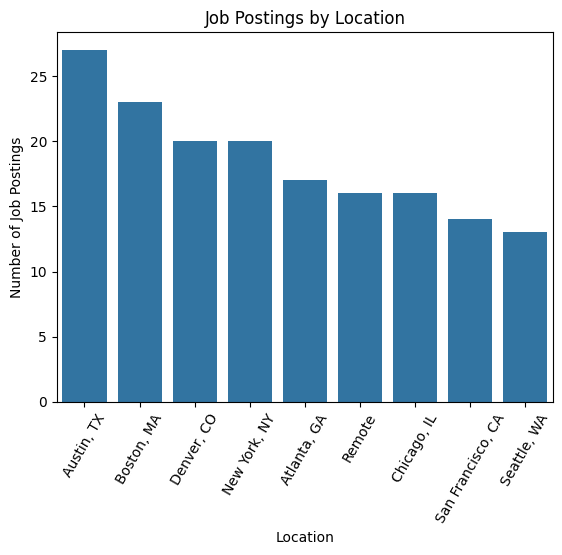

In [18]:
plt.figure()
sns.barplot(x=location.index, y=location.values)
plt.ylabel('Number of Job Postings')
plt.xlabel('Location')
plt.xticks(rotation=60)
plt.title("Job Postings by Location")
plt.show()

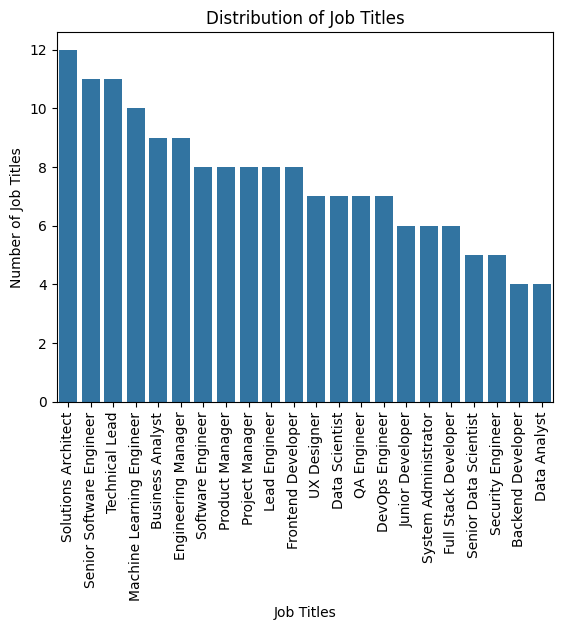

In [34]:
plt.figure()
sns.barplot(x=job_title.index, y=job_title.values)
plt.ylabel('Number of Job Titles')
plt.xlabel('Job Titles')
plt.xticks(rotation=90)
plt.title("Distribution of Job Titles")
plt.show()

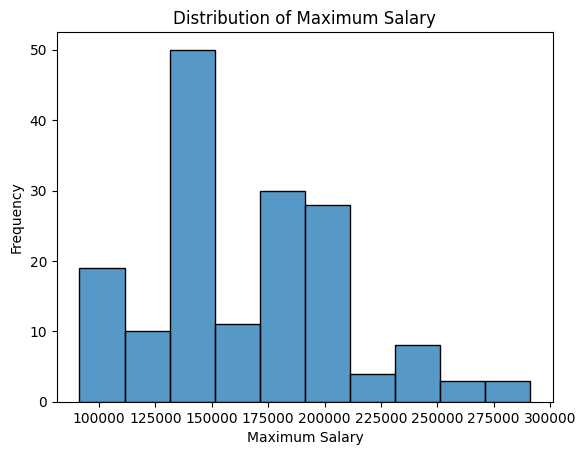

In [20]:
plt.figure()
sns.histplot(data=df, x="salary_max")
plt.title("Distribution of Maximum Salary")
plt.xlabel("Maximum Salary")
plt.ylabel("Frequency")
plt.show()

### Average Minimum Salary by Job Title

In [21]:
avg_salaries_by_job = df.groupby('job_title')[['salary_min', 'salary_max']].mean().reset_index()

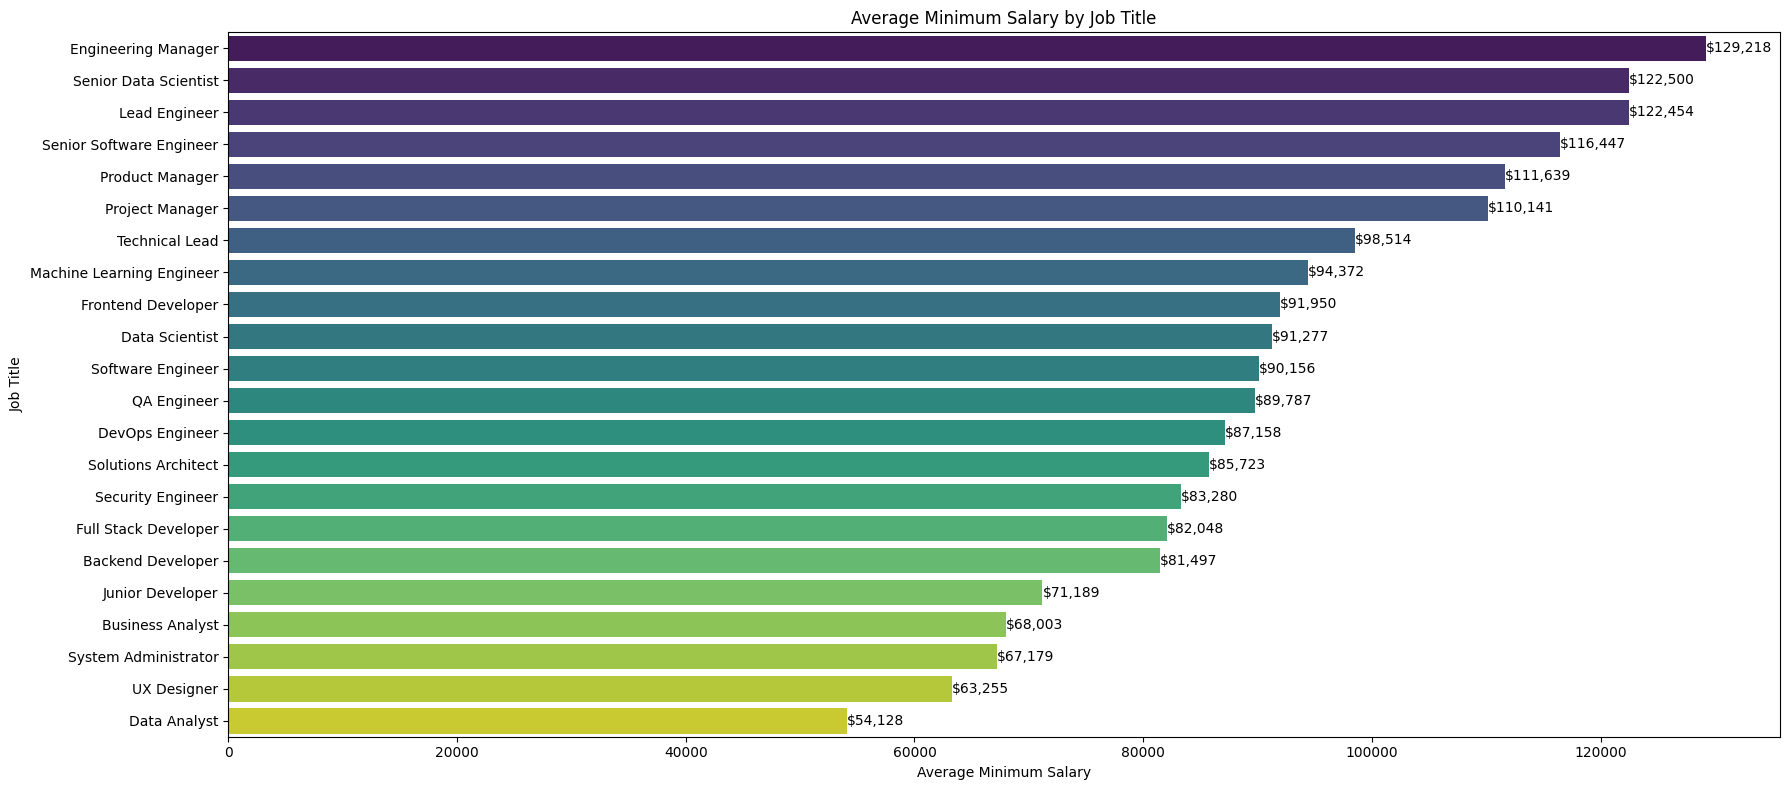

In [22]:
plt.figure(figsize=(18, 8))
ax_min = sns.barplot(y='job_title', x='salary_min', data=avg_salaries_by_job.sort_values(by='salary_min', ascending=False), palette='viridis', hue='job_title', legend=False)
plt.xlabel('Average Minimum Salary')
plt.ylabel('Job Title')
plt.title('Average Minimum Salary by Job Title')

# Add salary values at the end of each bar with a dollar sign
for container in ax_min.containers:
    ax_min.bar_label(container, fmt='${:,.0f}')

plt.tight_layout()
plt.show()

### Average Maximum Salary by Job Title

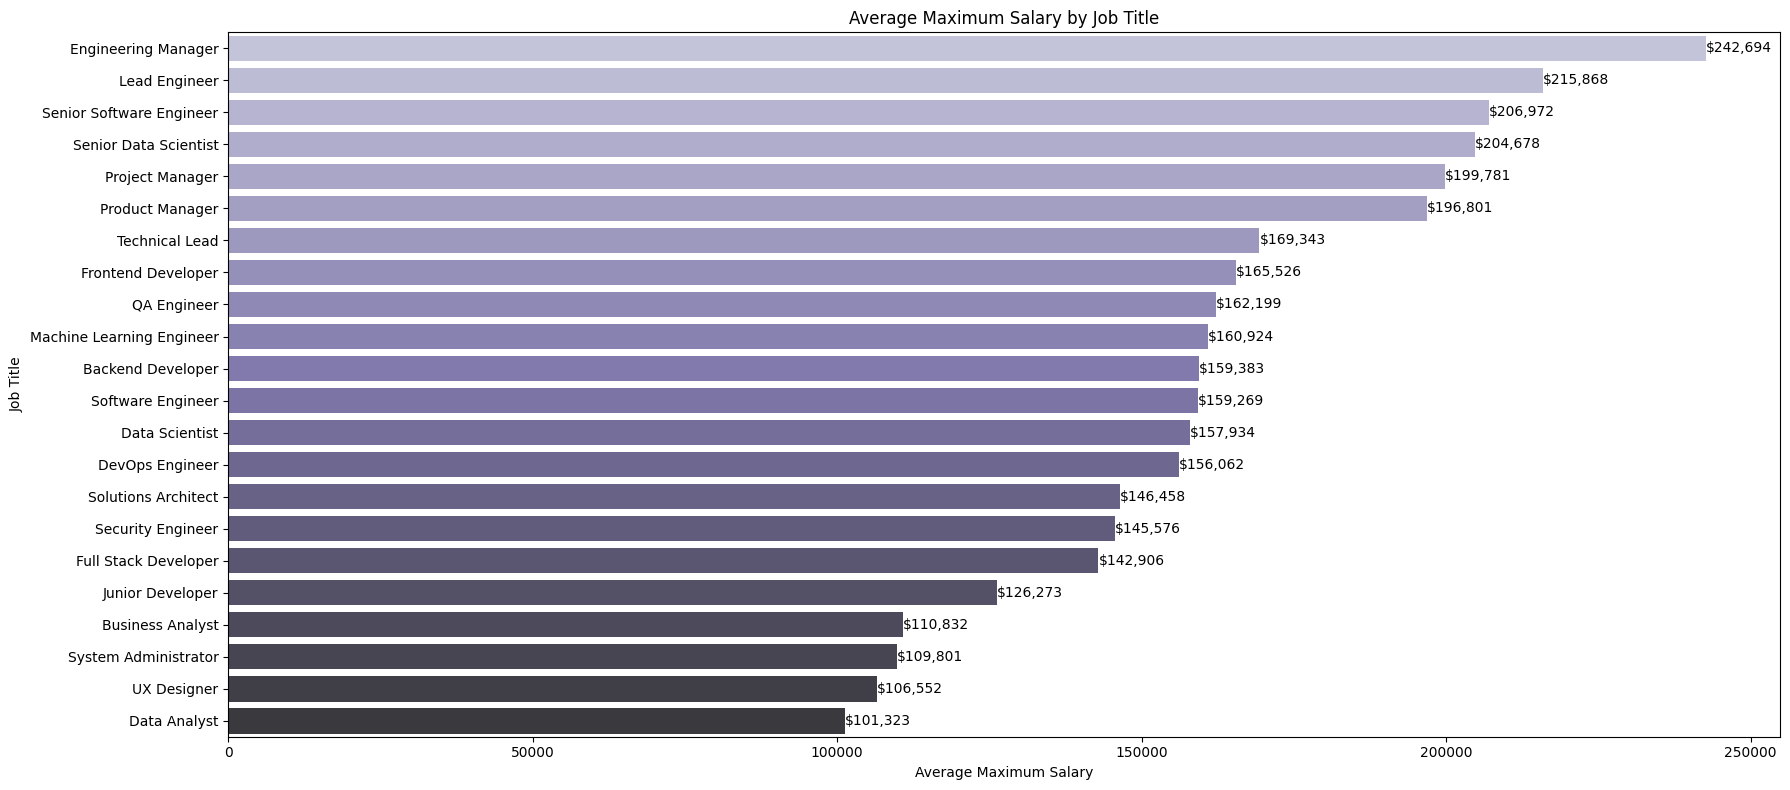

In [35]:
plt.figure(figsize=(18, 8))
ax_max = sns.barplot(y='job_title', x='salary_max', data=avg_salaries_by_job.sort_values(by='salary_max', ascending=False), palette='Purples_d', hue='job_title', legend=False)
plt.xlabel('Average Maximum Salary')
plt.ylabel('Job Title')
plt.title('Average Maximum Salary by Job Title')

# Add salary values at the end of each bar with a dollar sign
for container in ax_max.containers:
    ax_max.bar_label(container, fmt='${:,.0f}')

plt.tight_layout()
plt.show()

### Average Minimum Salary by Location

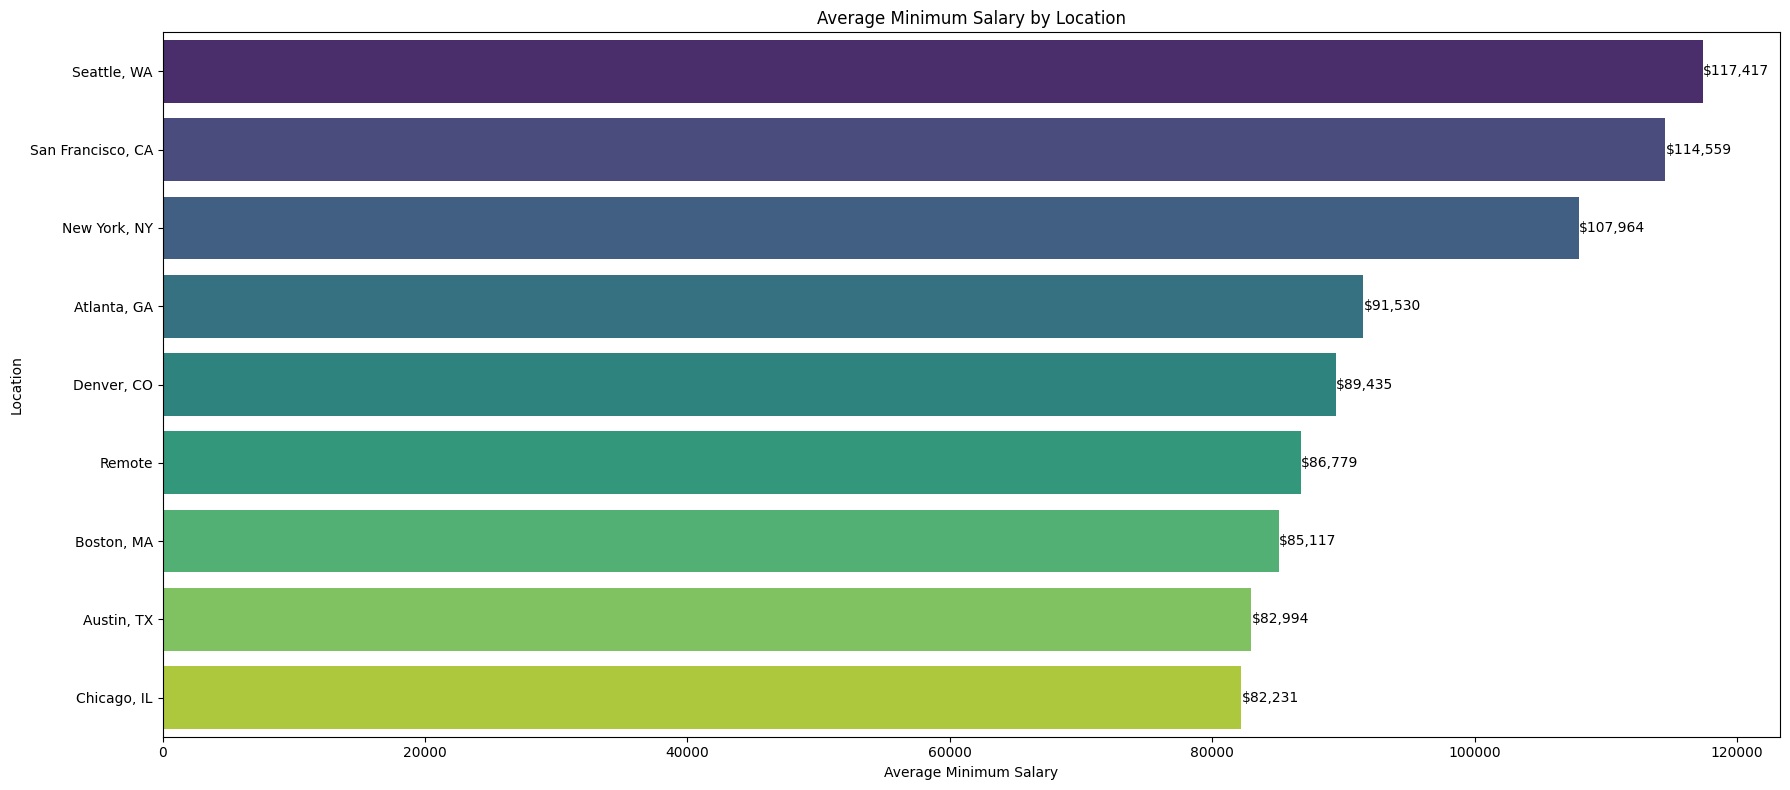

In [24]:
avg_salaries_by_location = df.groupby('location')[['salary_min', 'salary_max']].mean().reset_index()

plt.figure(figsize=(18, 8))
ax_loc_min = sns.barplot(y='location', x='salary_min', data=avg_salaries_by_location.sort_values(by='salary_min', ascending=False), palette='viridis', hue='location', legend=False)
plt.xlabel('Average Minimum Salary')
plt.ylabel('Location')
plt.title('Average Minimum Salary by Location')

for container in ax_loc_min.containers:
    ax_loc_min.bar_label(container, fmt='${:,.0f}')

plt.tight_layout()
plt.show()

### Average Maximum Salary by Location

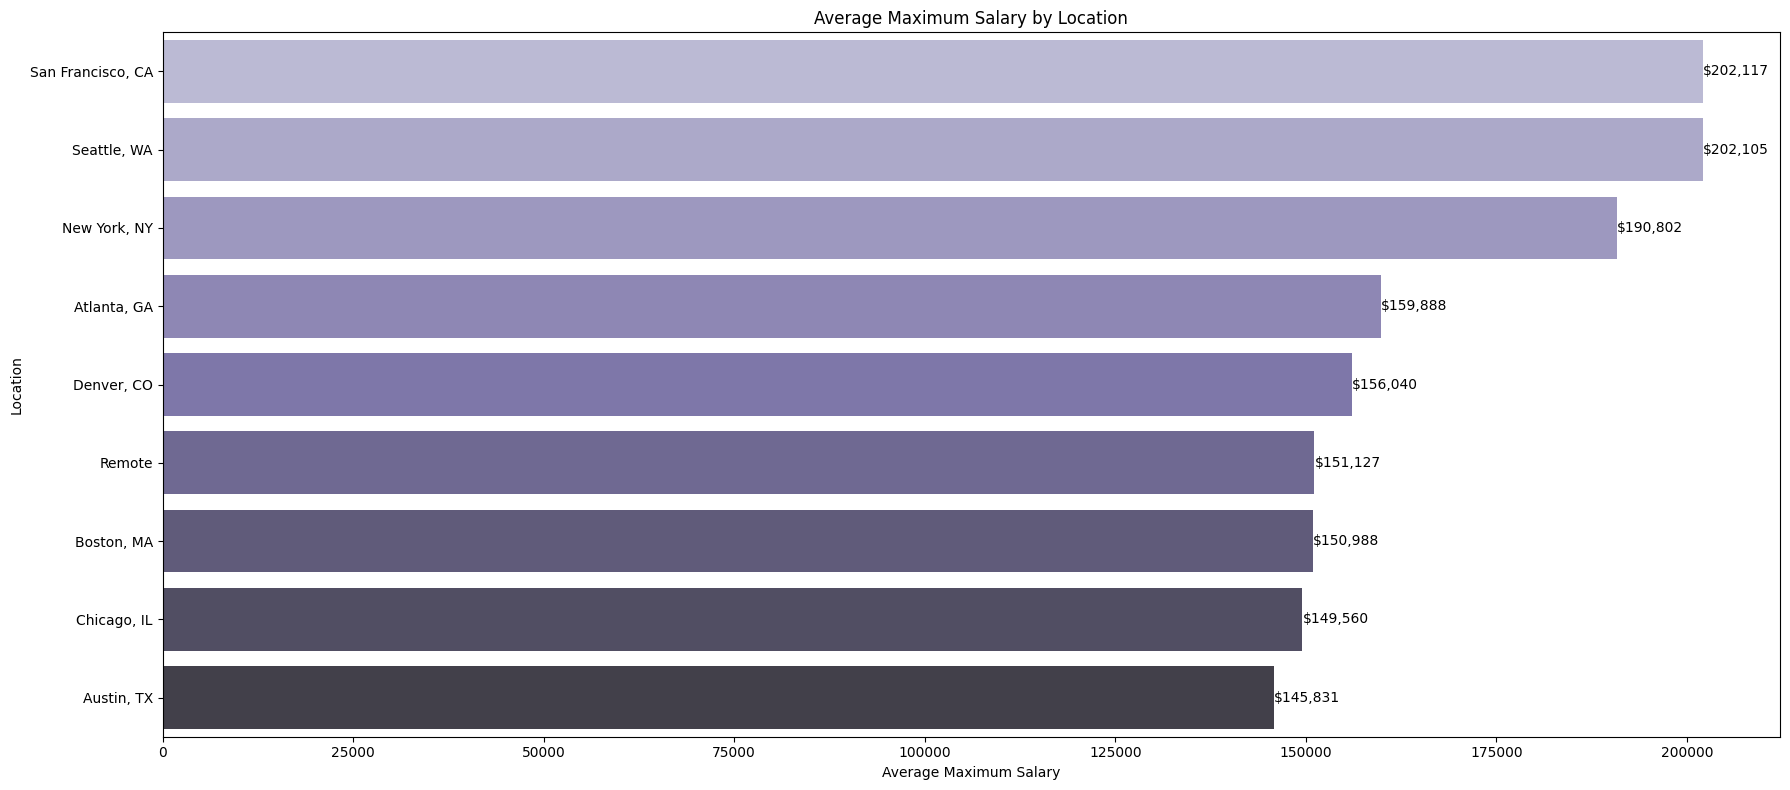

In [36]:
plt.figure(figsize=(18, 8))
ax_loc_max = sns.barplot(y='location', x='salary_max', data=avg_salaries_by_location.sort_values(by='salary_max', ascending=False), palette='Purples_d', hue='location', legend=False)
plt.xlabel('Average Maximum Salary')
plt.ylabel('Location')
plt.title('Average Maximum Salary by Location')

for container in ax_loc_max.containers:
    ax_loc_max.bar_label(container, fmt='${:,.0f}')

plt.tight_layout()
plt.show()

In [26]:
df.skills.value_counts()

,count
skills,
"AWS, Agile, Machine Learning, Kubernetes, MongoDB, Ruby",1
"Java, Agile, Git, SQL, Ruby, Go",1
"AWS, Python, Kubernetes, Git",1
"Agile, Git, Docker, REST APIs, TypeScript",1
"Agile, Ruby, Docker, Git, JavaScript",1
...,...
"SQL, MongoDB, Ruby, AWS",1
"AWS, JavaScript, Machine Learning, REST APIs, Python, Git, Go",1
"JavaScript, Kubernetes, TypeScript, Python, TensorFlow, Ruby, Git",1


/tmp/ipykernel_14424/2617178700.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_df, x='Count', y='Skill', palette='Blues')


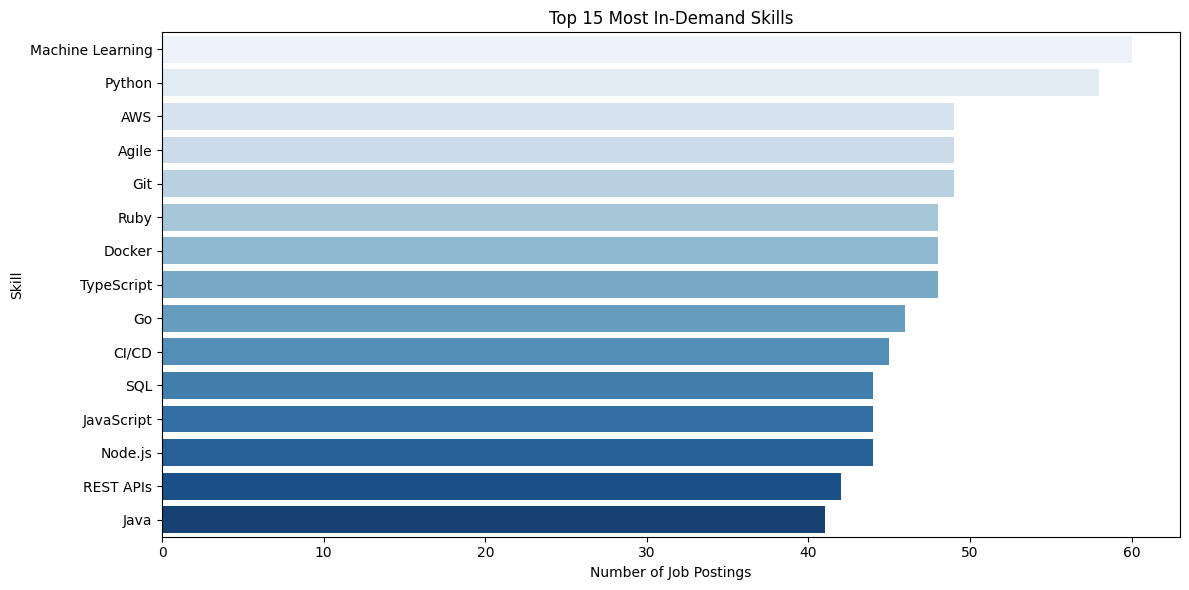

In [27]:
# Split skills into individual items and count each one
from collections import Counter

all_skills = df['skills'].dropna().str.split(', ')
skill_counts = Counter([skill for sublist in all_skills for skill in sublist])
skill_df = pd.DataFrame(skill_counts.most_common(15),
                         columns=['Skill', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=skill_df, x='Count', y='Skill', palette='Blues')
plt.title('Top 15 Most In-Demand Skills')
plt.xlabel('Number of Job Postings')
plt.tight_layout()
plt.show()

In [28]:
df['salary_mid'] = (df['salary_min'] + df['salary_max']) / 2

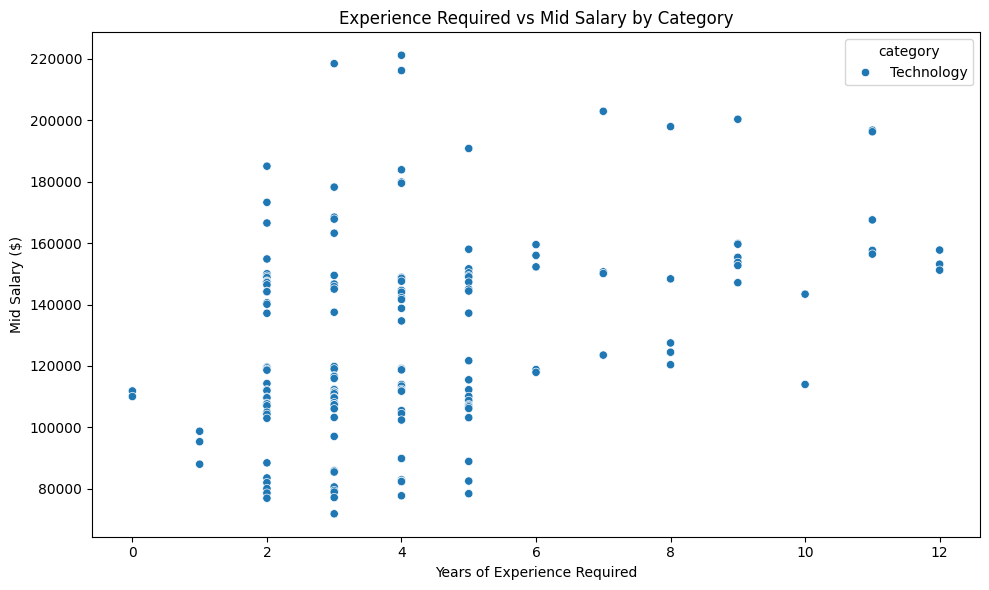

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='experience_required',
                y='salary_mid', hue='category')
plt.title('Experience Required vs Mid Salary by Category')
plt.xlabel('Years of Experience Required')
plt.ylabel('Mid Salary ($)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14424/978121632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='job_type', y='salary_mid', palette='pastel')


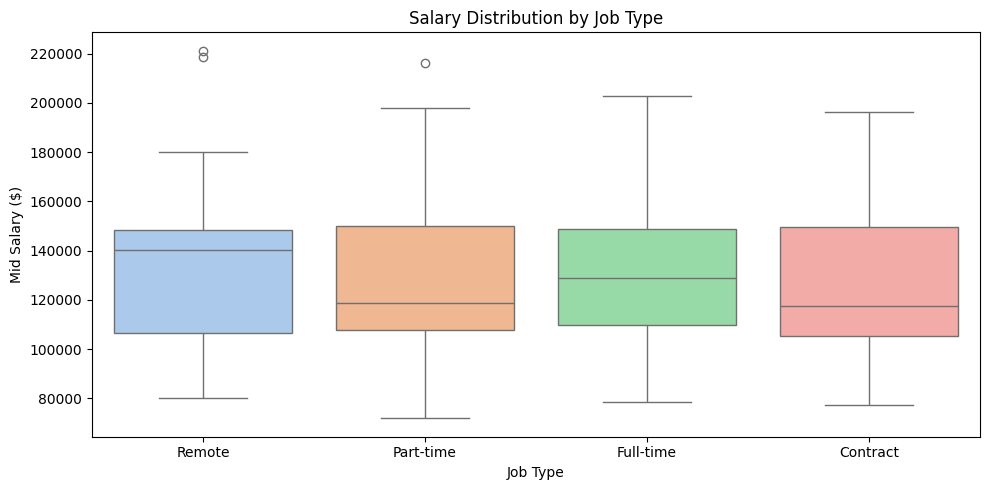

In [30]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='job_type', y='salary_mid', palette='pastel')
plt.title('Salary Distribution by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Mid Salary ($)')
plt.tight_layout()
plt.show()

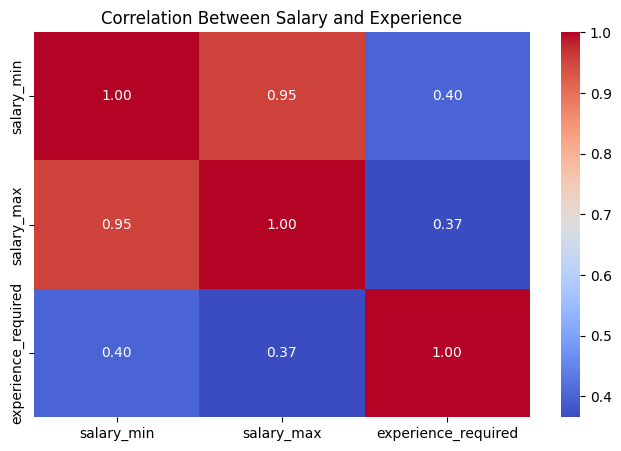

In [31]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['salary_min', 'salary_max',
                 'experience_required']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Salary and Experience')
plt.show()

Key Findings:
- Seattle and San Francisco offer the highest salaries
- Engineering Manager roles command the highest minimum salary at $129k

- Python, AWS, and Git are the top 3 most demanded skills
- Full-time and Contract roles offer similar salary ranges
- Each additional year of experience correlates with ~$X increase in salary

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create mid salary target variable
df['salary_mid'] = (df['salary_min'] + df['salary_max']) / 2

# Select features
features = ['job_title', 'location', 'job_type',
            'category', 'experience_required']
target = 'salary_mid'

# Drop rows with missing values in selected columns
model_df = df[features + [target]].dropna()

# Encode categorical variables
le = LabelEncoder()
for col in ['job_title', 'location', 'job_type', 'category']:
    model_df[col] = le.fit_transform(model_df[col])

# Split into train and test
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: ${mae:,.0f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error: $11,637
R² Score: 0.678


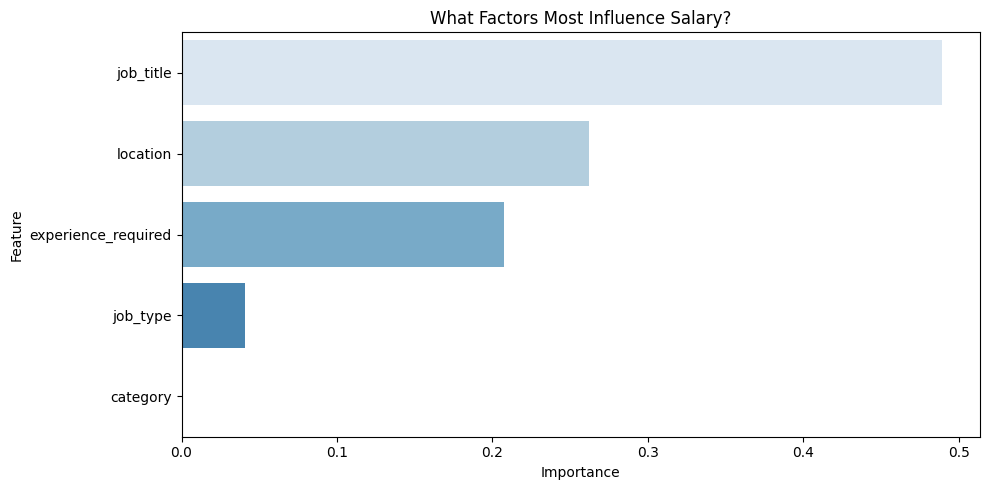

In [33]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importances, x='Importance', y='Feature',
            palette='Blues', hue='Feature', legend=False)
plt.title('What Factors Most Influence Salary?')
plt.tight_layout()
plt.show()